In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


#Drop ID

In [3]:
df = df.drop(columns=['id'])

#Convert age from days to years

In [4]:
df['age'] = (df['age'] / 365).astype(int)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


In [6]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,52.840671,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.766774,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


#Define X and y

In [8]:
X = df.drop(columns=['cardio'])
y = df['cardio']

# Encode Categorical Columns

In [9]:
categorical_cols = df.select_dtypes(include='object').columns
label_encoders = {}

In [10]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#Scale features

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data to:train,val,test

In [12]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42, stratify=y)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)

In [14]:
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (48998, 11)  Val: (10502, 11)  Test: (10500, 11)


#Define models

In [15]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, solver='lbfgs'),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
    'GradBoost': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

#Train & validate

In [16]:
all_results = []

def add_result(algo_name, params, y_tr_pred, y_tr_score, y_val_pred, y_val_score):
    all_results.append({
        "Algorithm": algo_name,
        "Hyperparameters": repr(params),
        "Train_Acc": accuracy_score(y_train, y_tr_pred),
        "Train_F1":  f1_score(y_train, y_tr_pred),
        "Train_AUC": roc_auc_score(y_train, y_tr_score),
        "Val_Acc":   accuracy_score(y_val, y_val_pred),
        "Val_F1":    f1_score(y_val, y_val_pred),
        "Val_AUC":   roc_auc_score(y_val, y_val_score),
    })


#LogisticRegression

In [17]:
logreg_params = [
    {"solver":"lbfgs", "C":1.0, "max_iter":1000},
    {"solver":"lbfgs", "C":0.5, "max_iter":1000},
    {"solver":"liblinear", "C":1.0, "max_iter":1000},
    {"solver":"saga", "C":1.0, "max_iter":1000},
    {"solver":"saga", "C":2.0, "max_iter":2000},
]

for p in logreg_params:
    model = LogisticRegression(**p, random_state=42)
    model.fit(X_train, y_train)

    y_tr_pred  = model.predict(X_train)
    y_tr_score = model.predict_proba(X_train)[:, 1]
    y_val_pred = model.predict(X_val)
    y_val_score= model.predict_proba(X_val)[:, 1]

    add_result("Logistic Regression", p, y_tr_pred, y_tr_score, y_val_pred, y_val_score)


#LogisticRegression plots

LogReg — Best Acc: 0.7161 | F1: 0.7026 | AUC: 0.7792 | Params: {'solver': 'liblinear', 'C': 1.0, 'max_iter': 1000}


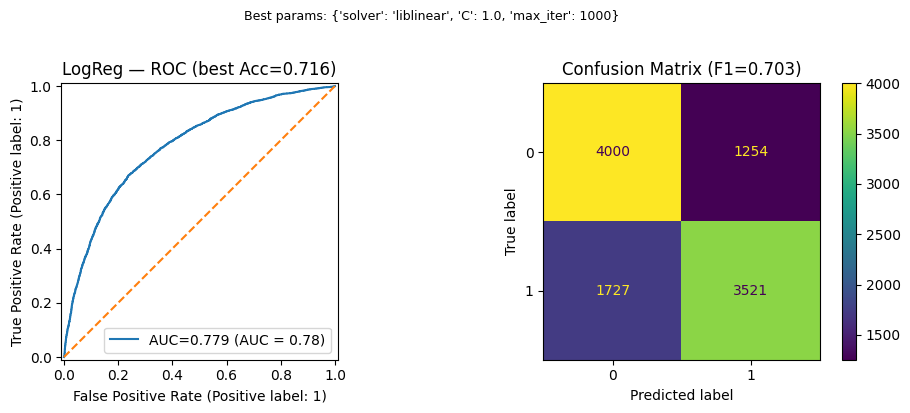

In [18]:
best_acc, best_p, best_clf = -1.0, None, None
for p in logreg_params[:5]:
    clf = make_pipeline(StandardScaler(), LogisticRegression(**p, random_state=42)).fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    if acc > best_acc: best_acc, best_p, best_clf = acc, p, clf

y_pred = best_clf.predict(X_val)
scores = best_clf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, scores)
f1  = f1_score(y_val, y_pred)
print(f"LogReg — Best Acc: {best_acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | Params: {best_p}")

cm = confusion_matrix(y_val, y_pred, labels=[0,1])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_val, scores, ax=ax[0], name=f"AUC={auc:.3f}")
ax[0].plot([0,1],[0,1],'--'); ax[0].set_title(f"LogReg — ROC (best Acc={best_acc:.3f})")
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d", ax=ax[1])
ax[1].set_title(f"Confusion Matrix (F1={f1:.3f})")
fig.suptitle(f"Best params: {best_p}", y=1.02, fontsize=9)
plt.tight_layout(); plt.show()


#RandomForestClassifier

In [19]:
rf_params = [
    {"n_estimators":100,  "max_depth":None, "min_samples_split":2,  "min_samples_leaf":1, "max_features":"sqrt"},
    {"n_estimators":200,  "max_depth":10,   "min_samples_split":2,  "min_samples_leaf":1, "max_features":"sqrt"},
    {"n_estimators":300,  "max_depth":20,   "min_samples_split":2,  "min_samples_leaf":1, "max_features":"sqrt"},
    {"n_estimators":500,  "max_depth":15,   "min_samples_split":5,  "min_samples_leaf":2, "max_features":"sqrt"},
    {"n_estimators":700,  "max_depth":None, "min_samples_split":10, "min_samples_leaf":4, "max_features":"sqrt"},
]

for p in rf_params:
    model = RandomForestClassifier(**p, random_state=42)
    model.fit(X_train, y_train)

    y_tr_pred  = model.predict(X_train)
    y_tr_score = model.predict_proba(X_train)[:, 1]
    y_val_pred = model.predict(X_val)
    y_val_score= model.predict_proba(X_val)[:, 1]

    add_result("Random Forest", p, y_tr_pred, y_tr_score, y_val_pred, y_val_score)


#RandomForestClassifier plots

RF — Best Acc: 0.7380 | F1: 0.7241 | AUC: 0.8027 | Params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


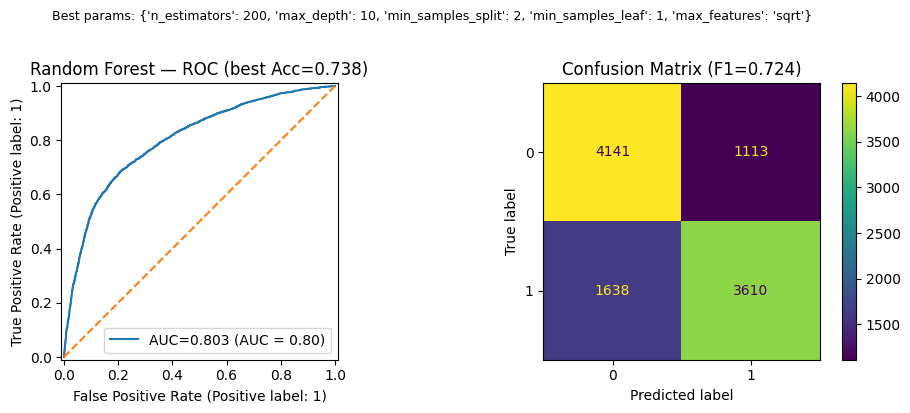

In [20]:
best_acc, best_p, best_clf = -1.0, None, None
for p in rf_params[:5]:
    clf = RandomForestClassifier(**p, random_state=42, n_jobs=-1).fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    if acc > best_acc: best_acc, best_p, best_clf = acc, p, clf

y_pred  = best_clf.predict(X_val)
scores  = best_clf.predict_proba(X_val)[:, 1]
auc     = roc_auc_score(y_val, scores)
f1      = f1_score(y_val, y_pred)
print(f"RF — Best Acc: {best_acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | Params: {best_p}")

cm = confusion_matrix(y_val, y_pred, labels=[0,1])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_val, scores, ax=ax[0], name=f"AUC={auc:.3f}")
ax[0].plot([0,1],[0,1],'--'); ax[0].set_title(f"Random Forest — ROC (best Acc={best_acc:.3f})")
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d", ax=ax[1])
ax[1].set_title(f"Confusion Matrix (F1={f1:.3f})")
fig.suptitle(f"Best params: {best_p}", y=1.02, fontsize=9)
plt.tight_layout(); plt.show()


#GradientBoostingClassifier




In [21]:
gb_params = [
    {"n_estimators":100,  "learning_rate":0.1,  "max_depth":3, "subsample":1.0},
    {"n_estimators":200,  "learning_rate":0.1,  "max_depth":3, "subsample":0.9},
    {"n_estimators":200,  "learning_rate":0.05, "max_depth":4, "subsample":0.9},
    {"n_estimators":300,  "learning_rate":0.05, "max_depth":5, "subsample":0.8},
    {"n_estimators":500,  "learning_rate":0.01, "max_depth":5, "subsample":0.8},
]

for p in gb_params:
    model = GradientBoostingClassifier(**p, random_state=42)
    model.fit(X_train, y_train)

    y_tr_pred  = model.predict(X_train)
    y_tr_score = model.predict_proba(X_train)[:, 1]
    y_val_pred = model.predict(X_val)
    y_val_score= model.predict_proba(X_val)[:, 1]

    add_result("Gradient Boosting", p, y_tr_pred, y_tr_score, y_val_pred, y_val_score)


#GradientBoostingClassifier plots

GB — Best Acc: 0.7371 | F1: 0.7255 | AUC: 0.8035 | Params: {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.8}


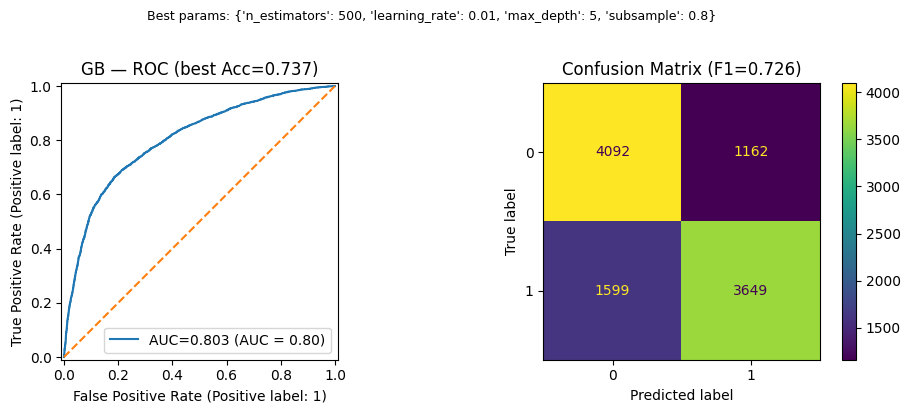

In [22]:
best_acc, best_p, best_clf = -1.0, None, None
for p in gb_params[:5]:
    clf = GradientBoostingClassifier(**p, random_state=42).fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    if acc > best_acc: best_acc, best_p, best_clf = acc, p, clf

y_pred = best_clf.predict(X_val)
scores = best_clf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, scores)
f1  = f1_score(y_val, y_pred)
print(f"GB — Best Acc: {best_acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | Params: {best_p}")

cm = confusion_matrix(y_val, y_pred, labels=[0,1])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_val, scores, ax=ax[0], name=f"AUC={auc:.3f}")
ax[0].plot([0,1],[0,1],'--'); ax[0].set_title(f"GB — ROC (best Acc={best_acc:.3f})")
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d", ax=ax[1])
ax[1].set_title(f"Confusion Matrix (F1={f1:.3f})")
fig.suptitle(f"Best params: {best_p}", y=1.02, fontsize=9)
plt.tight_layout(); plt.show()


#SupportVictorMachine

In [23]:
svm_params = [
    {"kernel":"rbf",    "C":0.5, "gamma":"scale"},
    {"kernel":"rbf",    "C":1.0, "gamma":"scale"},
    {"kernel":"rbf",    "C":2.0, "gamma":"auto"},
    {"kernel":"linear", "C":1.0},
    {"kernel":"poly",   "C":1.0, "degree":3, "gamma":"scale"},
]

for p in svm_params:
    model = SVC(**p, probability=False, cache_size=1000, max_iter=5000, random_state=42)
    model.fit(X_train, y_train)

    y_tr_pred  = model.predict(X_train)
    y_tr_score = model.decision_function(X_train)
    y_val_pred = model.predict(X_val)
    y_val_score= model.decision_function(X_val)

    add_result("SVM", p, y_tr_pred, y_tr_score, y_val_pred, y_val_score)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider

##SupportVictorMachine plots

SVM — Best Acc: 0.7247 | F1: 0.7146 | AUC: 0.7839 | Params: {'kernel': 'rbf', 'C': 2.0, 'gamma': 'auto'}


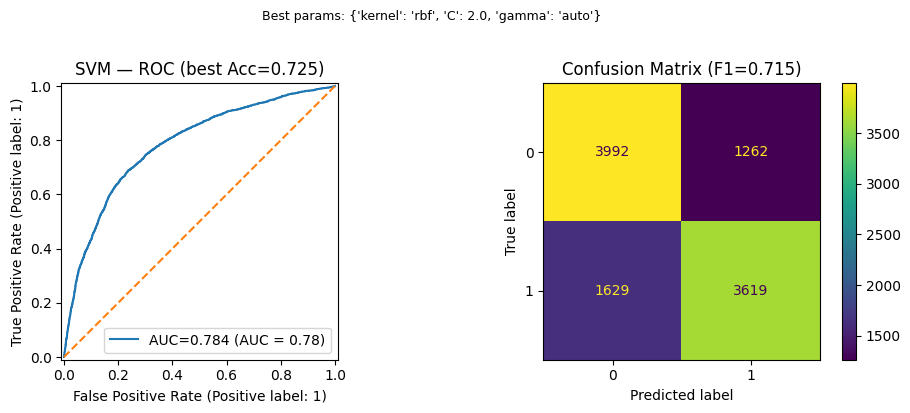

In [24]:
best_acc, best_p, best_clf = -1.0, None, None
for p in svm_params[:5]:
    clf = make_pipeline(StandardScaler(), SVC(**p, random_state=42)).fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    if acc > best_acc: best_acc, best_p, best_clf = acc, p, clf

y_pred = best_clf.predict(X_val)
last = best_clf[-1]
scores = best_clf.predict_proba(X_val)[:,1] if hasattr(last,"predict_proba") and getattr(last,"probability", False) else best_clf.decision_function(X_val)
auc = roc_auc_score(y_val, scores)
f1  = f1_score(y_val, y_pred)
print(f"SVM — Best Acc: {best_acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | Params: {best_p}")

cm = confusion_matrix(y_val, y_pred, labels=[0,1])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_val, scores, ax=ax[0], name=f"AUC={auc:.3f}")
ax[0].plot([0,1],[0,1],'--'); ax[0].set_title(f"SVM — ROC (best Acc={best_acc:.3f})")
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d", ax=ax[1])
ax[1].set_title(f"Confusion Matrix (F1={f1:.3f})")
fig.suptitle(f"Best params: {best_p}", y=1.02, fontsize=9)
plt.tight_layout(); plt.show()


#Results

In [26]:
from tabulate import tabulate
results_df = pd.DataFrame(all_results).round(4)
results_df = results_df.sort_values(["Algorithm", "Val_AUC"], ascending=[True, False])
print("\n=== All Results by Algorithm & Hyperparameters ===")
print(tabulate(results_df, headers="keys", tablefmt="pretty", showindex=False))


=== All Results by Algorithm & Hyperparameters ===
+---------------------+------------------------------------------------------------------------------------------------------------------+-----------+----------+-----------+---------+--------+---------+
|      Algorithm      |                                                 Hyperparameters                                                  | Train_Acc | Train_F1 | Train_AUC | Val_Acc | Val_F1 | Val_AUC |
+---------------------+------------------------------------------------------------------------------------------------------------------+-----------+----------+-----------+---------+--------+---------+
|  Gradient Boosting  |                  {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.8}                  |  0.7449   |  0.7349  |  0.8153   | 0.7371  | 0.7255 | 0.8035  |
|  Gradient Boosting  |                  {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.9}                 